## 1. Importação das Bibliotecas

In [1]:
# Instala o pacote watermark
!pip install -q -U watermark

In [2]:
# Imports
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, Markdown

In [3]:
# Configurações para melhor visualização
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [4]:
%reload_ext watermark
%watermark -a "Paulo Pereira"

Author: Paulo Pereira



In [5]:
%watermark --iversions

IPython    : 8.30.0
matplotlib : 3.10.0
numpy      : 2.1.3
pandas     : 2.3.1
plotly     : 5.24.1
seaborn    : 0.13.2
statsmodels: 0.14.4



## 2. Definição do Problema de Negócio

In [39]:
display(Markdown("""
## 2.1. Problema de Negócio

A **Banco Pereira**, uma empresa na área bancária, está enfrentando uma taxa de cancelamento de serviços (churn) acima da média nos tipos de contas (Corrente, Poupanã e PJ). A perda de clientes não só impacta a receita recorrente, mas também gera custos elevados com a aquisição de novos clientes para substituir os que foram perdidos.

O empresa precisa de respostas claras e baseadas em dados para a seguinte pergunta: **"Quais são os principais fatores que levam nossos clientes a cancelar o serviço?"**

- Queremos compreender a relação entre variáveis -> Modelagem Estatística
- Se quisermos prever o cancelamento (churn) -> Modelagem Preditiva

## 2.2. Objetivos do Projeto

Este projeto visa utilizar a modelagem estatística para analisar dados de clientes e atingir os seguintes objetivos:

1.  **Identificar os Fatores-Chave:** Determinar quais variáveis (como tipo de contrato, tempo de fidelidade, valor da fatura) têm um impacto estatisticamente significativo na probabilidade de um cliente cancelar o serviço.
2.  **Quantificar o Impacto:** Medir o quão forte é a influência de cada fator no risco de churn.
3.  **Gerar Recomendações:** Traduzir os resultados da análise estatística em recomendações de negócio acionáveis para a criação de estratégias de retenção de clientes.

O modelo escolhido para esta análise será a **Regressão Logística**, pois o nosso objetivo é entender a relação entre diversas variáveis e uma variável de resultado binária (Churn: Sim ou Não).
"""))


## 2.1. Problema de Negócio

A **Banco Pereira**, uma empresa na área bancária, está enfrentando uma taxa de cancelamento de serviços (churn) acima da média nos tipos de contas (Corrente, Poupanã e PJ). A perda de clientes não só impacta a receita recorrente, mas também gera custos elevados com a aquisição de novos clientes para substituir os que foram perdidos.

O empresa precisa de respostas claras e baseadas em dados para a seguinte pergunta: **"Quais são os principais fatores que levam nossos clientes a cancelar o serviço?"**

- Queremos compreender a relação entre variáveis -> Modelagem Estatística
- Se quisermos prever o cancelamento (churn) -> Modelagem Preditiva

## 2.2. Objetivos do Projeto

Este projeto visa utilizar a modelagem estatística para analisar dados de clientes e atingir os seguintes objetivos:

1.  **Identificar os Fatores-Chave:** Determinar quais variáveis (como tipo de contrato, tempo de fidelidade, valor da fatura) têm um impacto estatisticamente significativo na probabilidade de um cliente cancelar o serviço.
2.  **Quantificar o Impacto:** Medir o quão forte é a influência de cada fator no risco de churn.
3.  **Gerar Recomendações:** Traduzir os resultados da análise estatística em recomendações de negócio acionáveis para a criação de estratégias de retenção de clientes.

O modelo escolhido para esta análise será a **Regressão Logística**, pois o nosso objetivo é entender a relação entre diversas variáveis e uma variável de resultado binária (Churn: Sim ou Não).


In [40]:
## 3. Extração dos Dados

In [70]:
# Função para gerar dados fictícios mas coerentes para análise
def dsa_gera_dados_churn(num_clientes = 2000):
    
    """
    Gera um DataFrame de dados fictícios de clientes de uma empresa bancária.
    """

    # Para reprodutibilidade
    np.random.seed(42)  

    # Variáveis
    conta_fidelidade_ano = np.random.randint(1, 73, size = num_clientes)
    tipo_conta_opts = ['Anual', 'Cinco Anos', 'Vinte Anos']
    conta_probs = [0.6, 0.25, 0.15]
    tipo_contrato = np.random.choice(tipo_conta_opts, size = num_clientes, p = conta_probs)
    servico_conta_opts = ['Corrente', 'Poupança', 'PJ']
    tipo_service_probs = [0.55, 0.35, 0.10]
    servico_conta = np.random.choice(servico_conta_opts, size = num_clientes, p = tipo_service_probs)

    conta_base = {
        'Anual': np.random.normal(60, 20),
        'Cinco Anos': np.random.normal(70, 25),
        'Vinte Anos': np.random.normal(80, 25)
    }

    # Somatória dos dados de forma coerente
    conta_ano = [conta_base[c] + conta_fidelidade_ano[i] * 0.2 + np.random.normal(0, 5) for i, c in enumerate(tipo_contrato)]
    conta_ano = np.clip(conta_ano, 20, 120)

    # Lógica para a probabilidade de Churn
    # Clientes com contrato mensal, baixa fidelidade e fatura alta têm maior chance de churn
    prob_churn_log = -2.5  # Intercepto base (tendência a não cancelar)
    prob_churn_log += -0.05 * conta_fidelidade_ano  # Mais fidelidade, menor chance
    prob_churn_log += [3.0 if c == 'Anual' else -1.5 if c == 'Cinco Anos' else -2.5 for c in tipo_contrato] # Contrato mensal aumenta muito a chance
    prob_churn_log += [0.8 if s == 'Corrente' else -0.5 for s in servico_conta] # Fibra tende a ter mais churn (talvez por preço)
    prob_churn_log += 0.03 * conta_ano  # Fatura mais alta, mais chance
    
    # Converter log-odds para probabilidade usando a função sigmoide
    prob_churn = 1 / (1 + np.exp(-prob_churn_log))
    
    # Gerar o resultado de churn com base na probabilidade
    churn = np.random.binomial(1, prob_churn)

    df = pd.DataFrame({
        'ID_Cliente': range(1, num_clientes + 1),
        'Conta_Fidelidade_Ano': conta_fidelidade_ano,
        'Tipo_Contrato': tipo_contrato,
        'Servico_Conta': servico_conta,
        'Conta_Ano': conta_ano,
        'Churn': churn
    })

    return df

In [71]:
# Gera os dados
df_churn = dsa_gera_dados_churn()

In [72]:
display(Markdown("### Amostra dos Dados Gerados"))
df_churn.head()

### Amostra dos Dados Gerados

,ID_Cliente,Conta_Fidelidade_Ano,Tipo_Contrato,Servico_Conta,Conta_Ano,Churn
0,1,52,Cinco Anos,Corrente,36.5724,0
1,2,15,Vinte Anos,Corrente,45.2871,0
2,3,72,Anual,Corrente,101.0033,1
3,4,61,Anual,Corrente,103.3314,1
4,5,21,Anual,Poupança,94.0969,1


## 4. Análise Exploratória dos Dados (EDA)

In [73]:
# Informações gerais do DataFrame
display(Markdown("### Informações Gerais do DataFrame"))
df_churn.info()

### Informações Gerais do DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_Cliente            2000 non-null   int64  
 1   Conta_Fidelidade_Ano  2000 non-null   int32  
 2   Tipo_Contrato         2000 non-null   object 
 3   Servico_Conta         2000 non-null   object 
 4   Conta_Ano             2000 non-null   float64
 5   Churn                 2000 non-null   int32  
dtypes: float64(1), int32(2), int64(1), object(2)
memory usage: 78.3+ KB


In [74]:
# Resumo estatístico
display(Markdown("### Resumo Estatístico das Variáveis Numéricas"))
display(df_churn.describe())

### Resumo Estatístico das Variáveis Numéricas

,ID_Cliente,Conta_Fidelidade_Ano,Conta_Ano,Churn
count,2000.0000,2000.0000,2000.0000,2000.0000
mean,1000.5000,35.6825,75.3201,0.4905
std,577.4946,20.8430,27.5079,0.5000
min,1.0000,1.0000,24.9216,0.0000
25%,500.7500,17.0000,45.0201,0.0000
50%,1000.5000,35.0000,90.6543,0.0000
75%,1500.2500,54.0000,98.5286,1.0000
max,2000.0000,72.0000,119.2712,1.0000


In [75]:
# Resumo estatístico
display(Markdown("### Resumo Estatístico das Variáveis Categóricas"))
display(df_churn.describe(include='object'))

### Resumo Estatístico das Variáveis Categóricas

,Tipo_Contrato,Servico_Conta
count,2000,2000
unique,3,3
top,Anual,Corrente
freq,1186,1114


### 4.1. Gráfico de Taxa de Churn Geral

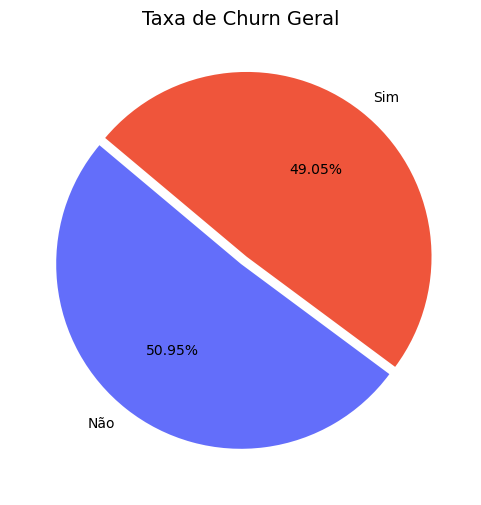

In [76]:
# Gráfico - Versão Estática

# Conta os valores da coluna 'Churn'
churn_counts = df_churn['Churn'].value_counts().rename(index = {1: 'Sim', 0: 'Não'})

# Define as cores equivalentes ao gráfico original
cores = ['#636EFA', '#EF553B']

# Cria o gráfico de pizza com duas casas decimais
plt.figure(figsize = (6,6))
plt.pie(
    churn_counts.values, 
    labels = churn_counts.index, 
    autopct = '%1.2f%%',   # <-- Duas casas decimais
    startangle = 140, 
    colors = cores,
    explode = [0.05 if label == 'Sim' else 0 for label in churn_counts.index]
)
plt.title('Taxa de Churn Geral', fontsize = 14)
plt.show()

In [77]:
# Calculamos a taxa de churn
churn_counts = df_churn['Churn'].value_counts()
numerador = churn_counts.get(1, churn_counts.get('Sim', churn_counts.get(True, 0)))
taxa = 100 * numerador / len(df_churn)

display(Markdown(f"""
A taxa de churn geral na nossa base de dados é de **{taxa:.2f}%**.
Este é o nosso principal indicador a ser analisado.
"""))


A taxa de churn geral na nossa base de dados é de **49.05%**.
Este é o nosso principal indicador a ser analisado.


### 4.2. Gráfico de Taxa de Churn Por Tipo de Contrato

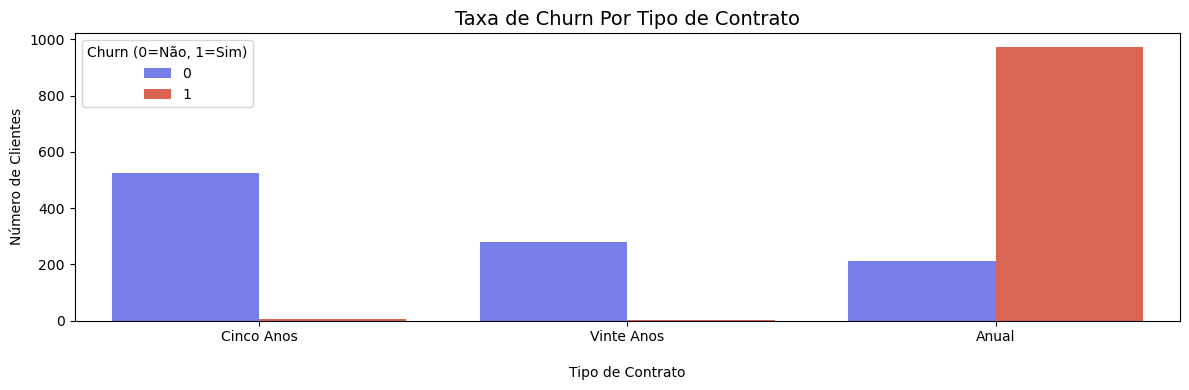

In [78]:
# Gráfico - Versão Estática

plt.figure(figsize = (12,4))

# Cria o gráfico de barras agrupadas com Seaborn
sns.countplot(data = df_churn,
              x = 'Tipo_Contrato',
              hue = 'Churn',
              palette = {0: '#636EFA', 1: '#EF553B'})

plt.title('Taxa de Churn Por Tipo de Contrato', fontsize = 14)
plt.xlabel('\nTipo de Contrato')
plt.ylabel('Número de Clientes')
plt.legend(title = 'Churn (0=Não, 1=Sim)')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

In [79]:
display(Markdown("""
**Insight:** A visualização é clara: clientes com **contrato anual** têm uma propensão ao churn drasticamente maior em comparação com clientes de contratos cinco anos ou de vinte anos.
"""))


**Insight:** A visualização é clara: clientes com **contrato anual** têm uma propensão ao churn drasticamente maior em comparação com clientes de contratos cinco anos ou de vinte anos.


## 5. Preparação dos Dados Para a Modelagem Estatística

In [80]:
# Dados originais
df_churn.head()

,ID_Cliente,Conta_Fidelidade_Ano,Tipo_Contrato,Servico_Conta,Conta_Ano,Churn
0,1,52,Cinco Anos,Corrente,36.5724,0
1,2,15,Vinte Anos,Corrente,45.2871,0
2,3,72,Anual,Corrente,101.0033,1
3,4,61,Anual,Corrente,103.3314,1
4,5,21,Anual,Poupança,94.0969,1


In [81]:
# Categorias da variável
df_churn.Tipo_Contrato.value_counts()

Tipo_Contrato
Anual         1186
Cinco Anos     533
Vinte Anos     281
Name: count, dtype: int64

In [82]:
# Categorias da variáve
df_churn.Servico_Conta.value_counts()

Servico_Conta
Corrente    1114
Poupança     690
PJ           196
Name: count, dtype: int64

In [83]:
# Preparação dos dados
# Converter variáveis categóricas em variáveis dummy (0 ou 1)
# Adicionado o parâmetro dtype=int para garantir que as novas colunas sejam numéricas
df_model = pd.get_dummies(df_churn, columns = ['Tipo_Contrato', 'Servico_Conta'], drop_first = True, dtype = int)

Variáveis dummy (ou variáveis indicadoras) são variáveis numéricas criadas para representar categorias em modelos estatísticos ou de Machine Learning. Elas transformam dados qualitativos (como “genero”, “estado civil”, “região”) em valores numéricos, geralmente 0 e 1, permitindo que algoritmos matemáticos consigam processá-los.

Assim, o modelo consegue interpretar diferenças entre grupos sem precisar lidar com texto. As variáveis dummy são uma forma de codificar categorias em números binários, facilitando análises estatísticas e predições. A técnica de criação de variáveis dummy é chamada de One-Hot-Encoding.

In [84]:
# Dados originais
df_churn.head()

,ID_Cliente,Conta_Fidelidade_Ano,Tipo_Contrato,Servico_Conta,Conta_Ano,Churn
0,1,52,Cinco Anos,Corrente,36.5724,0
1,2,15,Vinte Anos,Corrente,45.2871,0
2,3,72,Anual,Corrente,101.0033,1
3,4,61,Anual,Corrente,103.3314,1
4,5,21,Anual,Poupança,94.0969,1


In [85]:
# Dados processados
df_model.head()

,ID_Cliente,Conta_Fidelidade_Ano,Conta_Ano,Churn,Tipo_Contrato_Cinco Anos,Tipo_Contrato_Vinte Anos,Servico_Conta_PJ,Servico_Conta_Poupança
0,1,52,36.5724,0,1,0,0,0
1,2,15,45.2871,0,0,1,0,0
2,3,72,101.0033,1,0,0,0,0
3,4,61,103.3314,1,0,0,0,0
4,5,21,94.0969,1,0,0,0,1


In [86]:
# Resumo dos dados
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID_Cliente                2000 non-null   int64  
 1   Conta_Fidelidade_Ano      2000 non-null   int32  
 2   Conta_Ano                 2000 non-null   float64
 3   Churn                     2000 non-null   int32  
 4   Tipo_Contrato_Cinco Anos  2000 non-null   int64  
 5   Tipo_Contrato_Vinte Anos  2000 non-null   int64  
 6   Servico_Conta_PJ          2000 non-null   int64  
 7   Servico_Conta_Poupança    2000 non-null   int64  
dtypes: float64(1), int32(2), int64(5)
memory usage: 109.5 KB


In [87]:
# Definir as variáveis
# Variável dependente (o que queremos prever)
y = df_model['Churn']

In [88]:
# Variáveis independentes (as que usamos para prever)
# Excluímos a ID do cliente e a variável alvo original
X = df_model.drop(['ID_Cliente', 'Churn'], axis = 1)

In [89]:
# Adicionar uma constante (intercepto) ao modelo, exigido pela biblioteca statsmodels
X = sm.add_constant(X)

In [90]:
display(Markdown("### Amostra dos Dados (X) Preparados Para o Modelo"))
display(X.head())

### Amostra dos Dados (X) Preparados Para o Modelo

,const,Conta_Fidelidade_Ano,Conta_Ano,Tipo_Contrato_Cinco Anos,Tipo_Contrato_Vinte Anos,Servico_Conta_PJ,Servico_Conta_Poupança
0,1.0000,52,36.5724,1,0,0,0
1,1.0000,15,45.2871,0,1,0,0
2,1.0000,72,101.0033,0,0,0,0
3,1.0000,61,103.3314,0,0,0,0
4,1.0000,21,94.0969,0,0,0,1


In [91]:
display(Markdown("### Amostra dos Dados (y) Preparados Para o Modelo"))
display(y.head())

### Amostra dos Dados (y) Preparados Para o Modelo

0    0
1    0
2    1
3    1
4    1
Name: Churn, dtype: int32

## 6. Modelagem Estatística

In [92]:
display(Markdown("Vamos construir um modelo para quantificar o impacto de cada variável na probabilidade de churn."))

Vamos construir um modelo para quantificar o impacto de cada variável na probabilidade de churn.

In [93]:
# Criamos o modelo
modelo = sm.Logit(y, X)

In [94]:
type(modelo)

statsmodels.discrete.discrete_model.Logit

In [95]:
# Treinamento do modelo
modelo_treinado = modelo.fit()

Optimization terminated successfully.
         Current function value: 0.245933
         Iterations 10


In [96]:
# Exibir o resumo completo do modelo
display(Markdown("### Resultados do Modelo de Regressão Logística"))
modelo_treinado.summary()

### Resultados do Modelo de Regressão Logística

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 2000
Model:                          Logit   Df Residuals:                     1993
Method:                           MLE   Df Model:                            6
Date:                Tue, 24 Feb 2026   Pseudo R-squ.:                  0.6451
Time:                        09:09:56   Log-Likelihood:                -491.87
converged:                       True   LL-Null:                       -1385.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        1.5026      1.429      1.052      0.293      -1.298       4.303
Conta_Fidelidade_Ano        -0.0556      0.006     -9.883      0.000      -0.067      -0.045
Conta_Ano                    0.0316      0.016      2.004      0.045       0.001       0.062
Tipo_Contrato_Cinco Anos    -5.2739      0.934     -5.647      0.000      -7.104      -3.443
Tipo_Contrato_Vinte Anos    -6.5480      1.310     -4.998      0.000      -9.116      -3.980
Servico_Conta_PJ            -1.2454      0.272     -4.575      0.000      -1.779      -0.712
Servico_Conta_Poupança      -1.4550      0.180     -8.091      0.000      -1.807      -1.103
============================================================================================
"""

## 7. Interpretação dos Resultados

In [97]:
display(Markdown("""
O resumo acima contém informações ricas sobre o nosso modelo. Vamos focar nos pontos mais importantes para o negócio:

1.  **Coeficientes (`coef`):** Mostram a direção do impacto. Um coeficiente positivo aumenta a chance de churn, enquanto um negativo a diminui.
2.  **Valor-p (`P>|z|`):** Indica a significância estatística de cada variável. Um valor-p baixo (geralmente < 0.05) significa que o efeito da variável é real e não apenas uma coincidência na amostra.
3.  **Pseudo R-squ.:** Similar ao R² na regressão linear, indica a proporção da "variância" da variável dependente que é explicada pelo modelo. Um valor de 0.645 (ou 65%) é considerado um bom ajuste para este tipo de modelo.

Para facilitar a interpretação, vamos calcular a **Razão de Chances (Odds Ratio)**, que nos diz como as chances de churn mudam com o aumento de uma unidade na variável independente.
"""))


O resumo acima contém informações ricas sobre o nosso modelo. Vamos focar nos pontos mais importantes para o negócio:

1.  **Coeficientes (`coef`):** Mostram a direção do impacto. Um coeficiente positivo aumenta a chance de churn, enquanto um negativo a diminui.
2.  **Valor-p (`P>|z|`):** Indica a significância estatística de cada variável. Um valor-p baixo (geralmente < 0.05) significa que o efeito da variável é real e não apenas uma coincidência na amostra.
3.  **Pseudo R-squ.:** Similar ao R² na regressão linear, indica a proporção da "variância" da variável dependente que é explicada pelo modelo. Um valor de 0.645 (ou 65%) é considerado um bom ajuste para este tipo de modelo.

Para facilitar a interpretação, vamos calcular a **Razão de Chances (Odds Ratio)**, que nos diz como as chances de churn mudam com o aumento de uma unidade na variável independente.


A Razão de Chances (ou Odds Ratio) é uma medida usada para comparar a probabilidade de um evento ocorrer entre dois grupos. Ela é muito comum em estatística e modelos como a regressão logística.

De forma simples, a “chance” (odds) de um evento é a razão entre a probabilidade de ele acontecer e a probabilidade de não acontecer. Por exemplo, se a probabilidade de um cliente comprar um produto é 0,8 (80%), então a chance é 0,8 / 0,2 = 4. Isso quer dizer que a chance de compra é 4 vezes maior do que a de não compra.

In [98]:
# Calcular e exibir as razões de chance (Odds Ratios)
params = modelo_treinado.params
conf = modelo_treinado.conf_int()
conf['Odds Ratio'] = params
conf.columns = ['2.5%', '97.5%', 'Odds Ratio']
conf = np.exp(conf)
display(Markdown("### Tabela de Razão de Chances (Odds Ratio)"))
display(conf)

### Tabela de Razão de Chances (Odds Ratio)

,2.5%,97.5%,Odds Ratio
const,0.2731,73.9283,4.4934
Conta_Fidelidade_Ano,0.9355,0.9564,0.9459
Conta_Ano,1.0007,1.0644,1.0321
Tipo_Contrato_Cinco Anos,0.0008,0.0320,0.0051
Tipo_Contrato_Vinte Anos,0.0001,0.0187,0.0014
Servico_Conta_PJ,0.1688,0.4907,0.2878
Servico_Conta_Poupança,0.1641,0.3320,0.2334


## 8. Relatório Final - Conclusões e Recomendações Estratégicas

display(Markdown("""
# Relatório Final: Conclusões e Recomendações Estratégicas

## Conclusões

Foi realizada uma regressão logística para identificar fatores associados ao evento analisado. Observou-se que contratos de longo prazo (5 e 20 anos) apresentam Odds Ratio muito inferiores a 1, indicando forte redução na probabilidade do evento. Além disso, contas PJ e poupança também mostraram impacto negativo significativo. O tempo de conta apresentou efeito pequeno e próximo da neutralidade.